In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow
import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


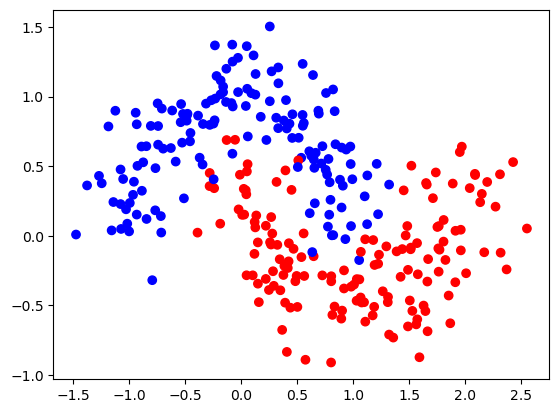

In [3]:
X,y = make_moons(n_samples=300 , noise=0.2 , random_state=42)
plt.scatter(X[:,0] , X[:,1] , c=y , cmap='bwr')
plt.show()

In [4]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2 , random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(240, 2)
(240,)
(60, 2)
(60,)


In [5]:
# let us scale the data
scaled  =StandardScaler()
X_train_scaled = scaled.fit_transform(X_train)
X_test_scaled = scaled.transform(X_test)

In [9]:
# Make the ANN Model
model = Sequential()
model.add(Dense(16 , activation='tanh' , input_dim = 2 , kernel_initializer='glorot_normal'))
model.add(Dense(1 , activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='Adam' , metrics = ['accuracy'])

c:\Users\Pradhuman\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.fit(X_train_scaled,y_train , validation_data = (X_test_scaled , y_test) , epochs=300,verbose=1)

Epoch 1/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.1667 - loss: 0.8035 - val_accuracy: 0.1167 - val_loss: 0.7884
Epoch 2/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1708 - loss: 0.7627 - val_accuracy: 0.1833 - val_loss: 0.7447
Epoch 3/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2333 - loss: 0.7244 - val_accuracy: 0.3500 - val_loss: 0.7030
Epoch 4/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5625 - loss: 0.6887 - val_accuracy: 0.7833 - val_loss: 0.6651
Epoch 5/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8042 - loss: 0.6570 - val_accuracy: 0.9000 - val_loss: 0.6294
Epoch 6/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8583 - loss: 0.6274 - val_accuracy: 0.8833 - val_loss: 0.5966
Epoch 7/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8583 - loss: 0.6001 - val_accuracy: 0.9000 - val_loss: 0.5665
Epoch 8/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8458 - loss: 0.5755 - val_accuracy: 0.9000 - val_loss: 0.5392

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 5s 500us/step


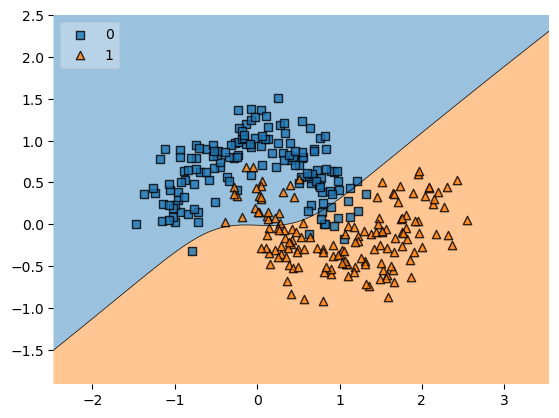

In [11]:
# Let us plot the regions
plot_decision_regions(X , y , clf=model , legend=2)
plt.show()

- THis looks pretty good, actually no overfitting issues can be seen -> using glorot_normal as kernel initializer

In [15]:
### Using He_uniform -> Change the activation to relu
# Make the ANN Model
model = Sequential()
model.add(Dense(16 , activation='relu' , input_dim = 2 , kernel_initializer='he_uniform'))
model.add(Dense(1 , activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='Adam' , metrics = ['accuracy'])

history = model.fit(X_train_scaled,y_train , validation_data = (X_test_scaled , y_test) , epochs=300,verbose=1)

Epoch 1/300


c:\Users\Pradhuman\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4375 - loss: 0.9158 - val_accuracy: 0.4333 - val_loss: 0.8836
Epoch 2/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4500 - loss: 0.8595 - val_accuracy: 0.4833 - val_loss: 0.8224
Epoch 3/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4583 - loss: 0.8077 - val_accuracy: 0.5333 - val_loss: 0.7661
Epoch 4/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4833 - loss: 0.7580 - val_accuracy: 0.5833 - val_loss: 0.7157
Epoch 5/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5125 - loss: 0.7156 - val_accuracy: 0.5833 - val_loss: 0.6685
Epoch 6/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5500 - loss: 0.6747 - val_accuracy: 0.6000 - val_loss: 0.6264
Epoch 7/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5625 - loss: 0.6398 - val_accuracy: 0.6667 - val_loss: 0.5883
Epoch 8/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5875 - loss: 0.6052 - val_accuracy: 0.7000 - val_loss: 0.5556
Epoch 9/300

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 6s 594us/step


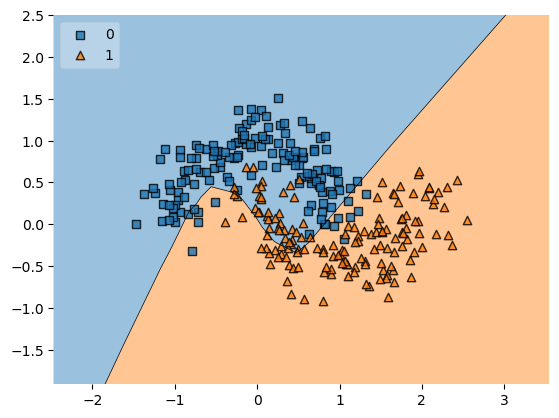

In [14]:
# Let us plot the regions
plot_decision_regions(X , y , clf=model , legend=2)
plt.show()

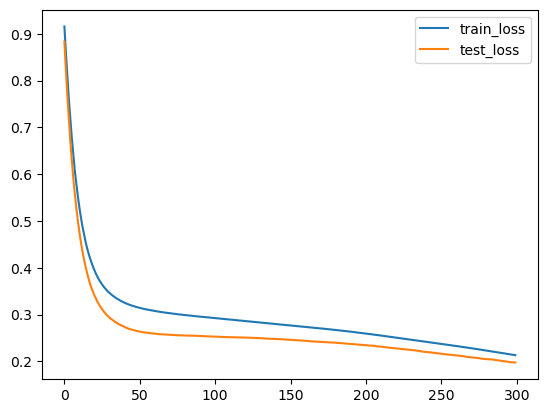

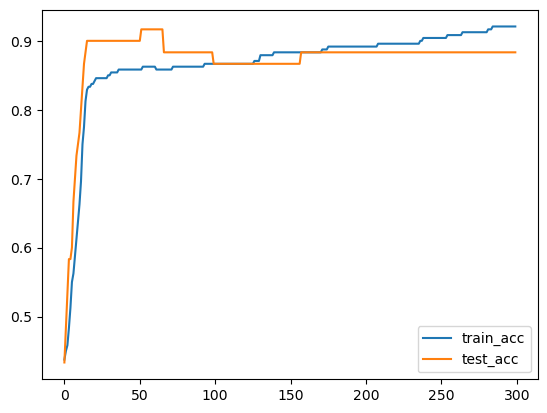

In [17]:
plt.plot(history.history['loss'],label='train_loss')
plt.plot(history.history['val_loss'],label='test_loss')
plt.legend()
plt.show()
plt.plot(history.history['accuracy'],label='train_acc')
plt.plot(history.history['val_accuracy'],label='test_acc')
plt.legend()
plt.show()